In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
transactions = pd.read_csv('transactions_clean.csv')
transactions.head()

,TransactionID,CustomerID,Date,BranchID,Type,Channel,Amount,Year,Month,Month_Name
0,1,109672,2024-03-23,B023,Deposit,UPI,651499,2024,3,March
1,2,106047,2025-05-12,B005,Deposit,UPI,1177900,2025,5,May
2,3,109137,2023-04-21,B038,Withdrawal,NetBanking,37871,2023,4,April
3,4,102122,2026-05-18,B004,Deposit,UPI,1035154,2026,5,May
4,5,102406,2026-05-29,B008,Withdrawal,UPI,605737,2026,5,May


In [6]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249400 entries, 0 to 249399
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   TransactionID  249400 non-null  int64         
 1   CustomerID     249400 non-null  int64         
 2   Date           249400 non-null  datetime64[ns]
 3   BranchID       249400 non-null  object        
 4   Type           249400 non-null  object        
 5   Channel        249400 non-null  object        
 6   Amount         249400 non-null  int64         
 7   Year           249400 non-null  int64         
 8   Month          249400 non-null  int64         
 9   Month_Name     249400 non-null  object        
dtypes: datetime64[ns](1), int64(5), object(4)
memory usage: 19.0+ MB


In [5]:
transactions['Date']=pd.to_datetime(transactions['Date'])

In [7]:
transactions.describe()

,TransactionID,CustomerID,Date,Amount,Year,Month
count,249400.000000,249400.000000,249400,2.494000e+05,249400.000000,249400.000000
mean,124988.767682,107504.278974,2024-09-20 18:45:07.361667840,7.505394e+05,2024.259711,6.079848
min,1.000000,100001.000000,2023-01-01 00:00:00,1.230000e+02,2023.000000,1.000000
25%,62475.750000,103753.000000,2023-11-11 00:00:00,3.764098e+05,2023.000000,3.000000
50%,124981.500000,107506.000000,2024-09-20 00:00:00,7.494205e+05,2024.000000,6.000000
75%,187497.250000,111243.000000,2025-08-01 00:00:00,1.125179e+06,2025.000000,9.000000
max,250000.000000,115000.000000,2026-06-13 00:00:00,1.499998e+06,2026.000000,12.000000
std,72171.188596,4328.153113,NaN,4.326709e+05,1.016064,3.441052


In [8]:
transactions['Type'].value_counts()

Type
Deposit       159494
Withdrawal     89906
Name: count, dtype: int64

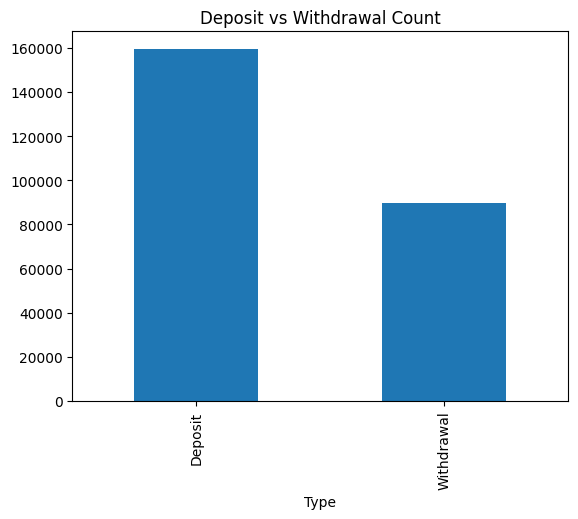

In [10]:
transactions['Type'].value_counts().plot(kind='bar')
plt.title('Deposit vs Withdrawal Count')
plt.show()

# total deposit and withdrawal amount

In [11]:
transactions.groupby('Type')['Amount'].sum()

Type
Deposit       119734013636
Withdrawal     67450516670
Name: Amount, dtype: int64

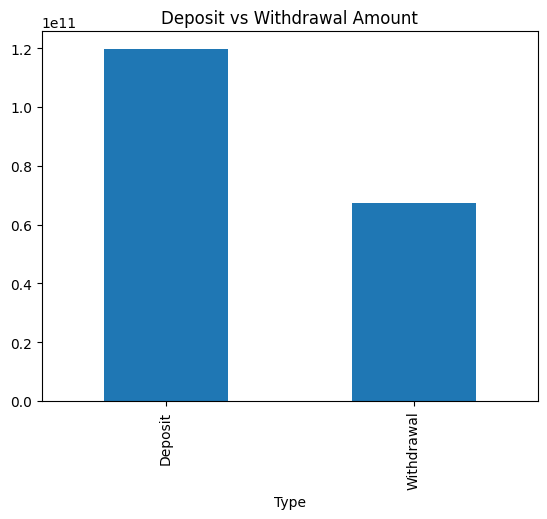

In [12]:
transactions.groupby('Type')['Amount'].sum().plot(kind='bar')

plt.title('Deposit vs Withdrawal Amount')

plt.show()

# transaction channel usage

In [13]:
transactions['Channel'].value_counts()

Channel
UPI           50082
Branch        49903
Card          49839
NetBanking    49829
ATM           49747
Name: count, dtype: int64

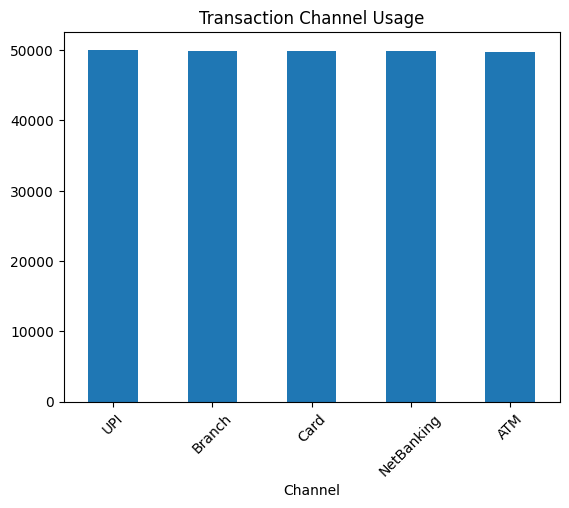

In [14]:
transactions['Channel'].value_counts().plot(kind='bar')

plt.title('Transaction Channel Usage')

plt.xticks(rotation=45)

plt.show()

# Channel-wise Transaction Amount

In [15]:
transactions.groupby('Channel')['Amount'].sum().sort_values(ascending=False)

Channel
UPI           37539767676
Card          37500507806
Branch        37452665182
NetBanking    37360054098
ATM           37331535544
Name: Amount, dtype: int64

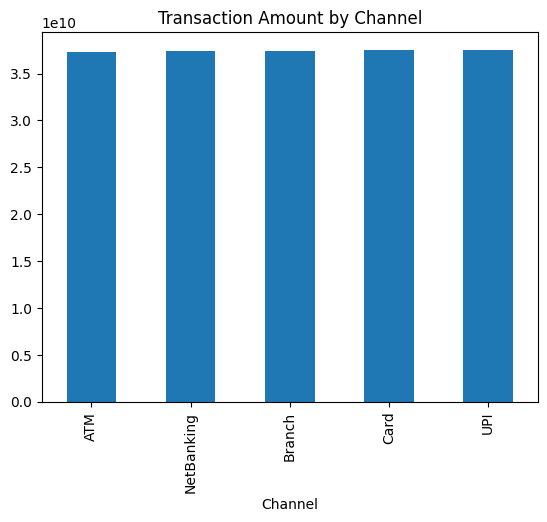

In [16]:
transactions.groupby('Channel')['Amount'].sum().sort_values().plot(kind='bar')

plt.title('Transaction Amount by Channel')

plt.show()

# Create year and month

In [17]:
transactions['Year']=transactions['Date'].dt.year

transactions['Month']= transactions['Date'].dt.month

transactions['MonthName']=transactions['Date'].dt.month_name()

In [18]:
monthly=transactions.groupby(['Year','Month'])['Amount'].sum()

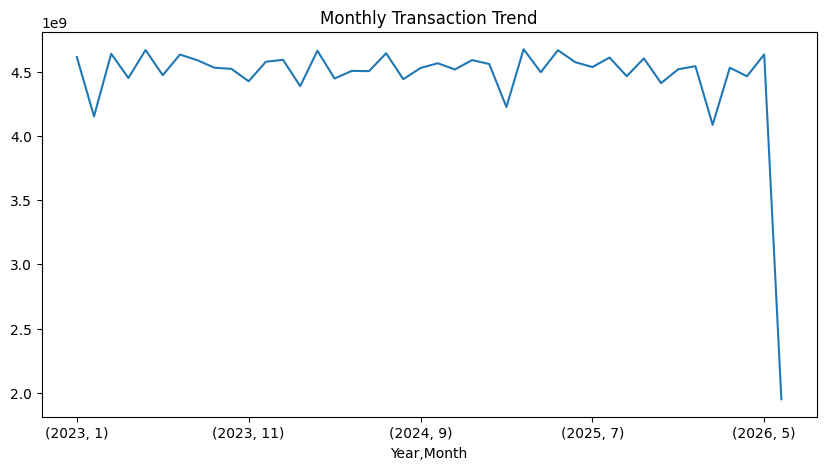

In [19]:
monthly.plot(figsize=(10,5))

plt.title('Monthly Transaction Trend')

plt.show()

# Monthly Deposite Trend

In [21]:
deposit=transactions[transactions['Type']=='Deposit'].groupby(['Year','Month'])['Amount'].sum()

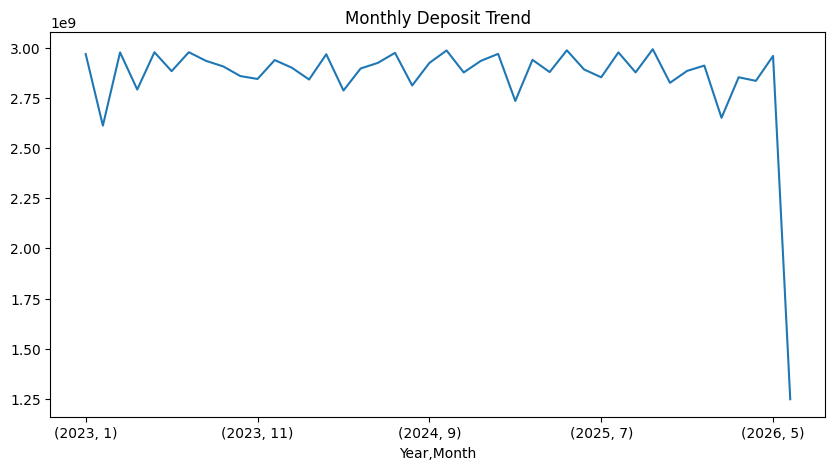

In [22]:
deposit.plot(figsize=(10,5))

plt.title('Monthly Deposit Trend')

plt.show()

# monthly Withdrawal Trend

In [23]:
withdraw = transactions[transactions['Type']=='Withdrawal'].groupby(['Year','Month'])['Amount'].sum()

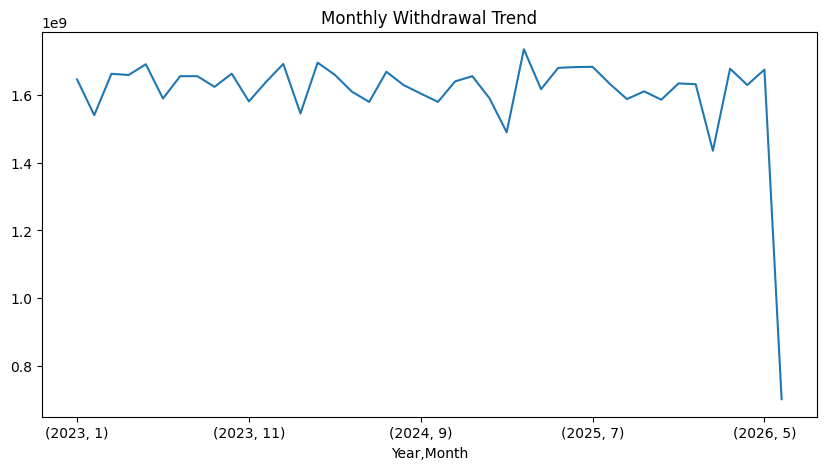

In [24]:
withdraw.plot(figsize =(10,5))
plt.title('Monthly Withdrawal Trend')
plt.show()

# Branch Performance

In [25]:
transactions.groupby('BranchID')['Amount'].sum().sort_values(ascending=False).head(10)

BranchID
B028    3908841661
B033    3872357487
B009    3870892073
B035    3859311252
B027    3851983025
B005    3827739625
B034    3823934310
B016    3823723526
B045    3823306272
B025    3815552307
Name: Amount, dtype: int64

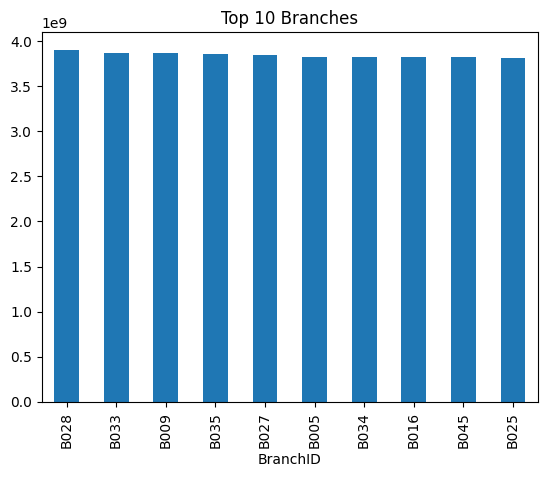

In [26]:
transactions.groupby('BranchID')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')

plt.title('Top 10 Branches')

plt.show()

# Largest Transactions

In [27]:
transactions.sort_values('Amount',ascending=False).head(10)

,TransactionID,CustomerID,Date,BranchID,Type,Channel,Amount,Year,Month,Month_Name,MonthName
103443,103677,107870,2023-05-16,B027,Withdrawal,Branch,1499998,2023,5,May,May
5676,5693,101434,2025-12-28,B025,Withdrawal,Card,1499996,2025,12,December,December
193502,193959,111259,2025-03-24,B024,Withdrawal,NetBanking,1499991,2025,3,March,March
136037,136358,111253,2025-09-30,B015,Withdrawal,ATM,1499983,2025,9,September,September
58265,58382,114983,2025-08-24,B029,Withdrawal,ATM,1499962,2025,8,August,August
155610,155983,107862,2023-10-28,B033,Withdrawal,Card,1499959,2023,10,October,October
171751,172153,107891,2025-05-11,B043,Deposit,NetBanking,1499956,2025,5,May,May
109224,109469,104780,2025-05-05,B025,Deposit,Card,1499952,2025,5,May,May
183228,183665,101001,2026-03-31,B019,Deposit,Branch,1499949,2026,3,March,March
190287,190737,112871,2026-02-20,B015,Deposit,ATM,1499940,2026,2,February,February


# Average Transaction by Channel

In [28]:
transactions.groupby('Channel')['Amount'].mean()

Channel
ATM           750427.875932
Branch        750509.291666
Card          752432.990349
NetBanking    749765.279215
UPI           749566.065173
Name: Amount, dtype: float64

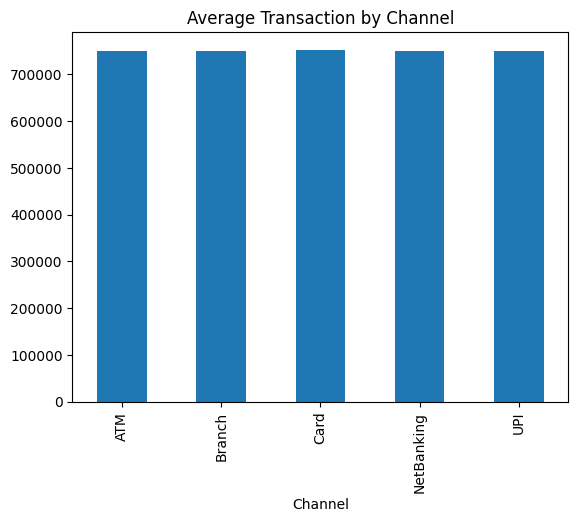

In [29]:
transactions.groupby('Channel')['Amount'].mean().plot(kind='bar')

plt.title('Average Transaction by Channel')

plt.show()

# Top 10 Customers by Transaction Amount

In [30]:
transactions.groupby('CustomerID')['Amount'].sum().sort_values(ascending=False).head(10)

CustomerID
108808    29270281
107596    28676644
103656    28585269
111920    28212794
105849    28018319
100105    26841342
102367    26821155
112672    26548875
110266    25651396
101732    25356352
Name: Amount, dtype: int64

In [31]:
transactions.to_csv('transactions_analytics.csv',index=False)

Insights
UPI is the most used channel.

Deposits are higher than withdrawals.
Transactions show seasonal trends.

Top 10 branches contribute significant transaction volume.

Some customers are responsible for very high transaction amounts.